In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy.io
import h5py
import numpy as np
import warnings
import random
import torch.nn.init as init
from scipy.io import savemat
import math
import os
import torch.nn.functional as F
from tqdm import tqdm
from torch.utils.data import TensorDataset, DataLoader

import pandas as pd
warnings.filterwarnings('ignore')

with torch.no_grad():

  torch.cuda.empty_cache()

torch.set_default_dtype(torch.float64)


In [2]:
# Number of GPU used
warnings.filterwarnings("ignore")
torch.set_default_dtype(torch.float64)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MULTI_GPU = torch.cuda.device_count() > 1
print(f"Running on {DEVICE} with {torch.cuda.device_count()} GPUs")


Running on cuda with 1 GPUs


In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib.font_manager")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)


In [4]:
# reading the data
# current 50 neighbor data is selected from 72 points
df = pd.read_csv('dataset_50_spatialpoints_partialsignal_mixed_rec_neighbor_50inrange.csv')


In [5]:
df.isnull().sum()


,0
x,0
y,0
z,0
t,0
u,0
v,0
w,0


# Distribution in Original Data

In [6]:
def power10_bucket_counts_before_after(df):

    means = df.mean(axis=0)
    stds = df.std(axis=0)
    stds_repl = stds.replace(0, 1.0)
    df_std = (df - means) / stds_repl

    def min_max_exp_from_df(dframe):
        min_exp, max_exp = 100, -100
        for col in dframe.columns:
            vals = np.abs(dframe[col].values.ravel())
            nonzero = vals[vals != 0.0]
            if nonzero.size == 0:
                continue
            lo = int(np.floor(np.log10(nonzero.min())))
            hi = int(np.floor(np.log10(nonzero.max())))
            if lo < min_exp:
                min_exp = lo
            if hi > max_exp:
                max_exp = hi
        return min_exp, max_exp

    min_before, max_before = min_max_exp_from_df(df)
    min_after,  max_after  = min_max_exp_from_df(df_std)

    print("Lowest/Highest exponent BEFORE standardization:", (min_before, max_before))
    print("Lowest/Highest exponent AFTER  standardization:", (min_after, max_after))

    overall_min = min(min_before, min_after)
    overall_max = max(max_before, max_after)
    exps = list(range(overall_min, overall_max + 1))

    index = ["0"] + [f"10^{k}" for k in exps]

    # prepare output columns: for each original col -> col_before, col_after
    out_cols = []
    for c in df.columns:
        out_cols.append(f"{c}_before")
        out_cols.append(f"{c}_after")

    counts_df = pd.DataFrame(0, index=index, columns=out_cols, dtype=int)

    def fill_counts(colname, values, suffix):
        absvals = np.abs(values.ravel())
        zeros = int((absvals == 0.0).sum())
        counts_df.at["0", f"{colname}_{suffix}"] = zeros
        nonzero = absvals[absvals != 0.0]

        for k in exps:
            low = 10.0 ** k
            high = 10.0 ** (k + 1)
            cnt = int(((nonzero >= low) & (nonzero < high)).sum())
            counts_df.at[f"10^{k}", f"{colname}_{suffix}"] = cnt

    for c in df.columns:
        fill_counts(c, df[c].values, "before")
        fill_counts(c, df_std[c].values, "after")

    return counts_df

counts = power10_bucket_counts_before_after(df)
display(counts)


Lowest/Highest exponent BEFORE standardization: (-37, 0)
Lowest/Highest exponent AFTER  standardization: (-16, 0)


,x_before,x_after,y_before,y_after,z_before,z_after,t_before,t_after,u_before,u_after,v_before,v_after,w_before,w_after
0,0,0,0,0,150025,150025,0,0,52165,0,52157,0,52157,0
10^-37,0,0,0,0,0,0,0,0,0,0,0,0,12,0
10^-36,0,0,0,0,0,0,0,0,11,0,0,0,13,0
10^-35,0,0,0,0,0,0,0,0,1,0,0,0,0,0
10^-34,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-33,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-32,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-31,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-30,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-29,0,0,0,0,0,0,0,0,0,0,0,0,0,0


# Distribution after dropping rows

# Standardization and distribution after standardization

In [7]:
# sending the non threshold less
# it has been checked that applying the threshold does not change much of the mean and std value
means = df.mean(axis=0)
print('means of df:', means)
stds = df.std(axis=0)
print('stds of df:', stds)
stds_repl = stds.replace(0, 1.0)
df_std = (df - means) / stds_repl

print(df_std.shape)


means of df: x    1.351208e-01
y   -3.266979e+00
z    0.000000e+00
t    3.001000e-05
u   -8.994292e-09
v   -2.380022e-09
w   -3.288451e-09
dtype: float64
stds of df: x    3.473849e+00
y    1.574698e+00
z    0.000000e+00
t    1.732345e-05
u    2.442149e-06
v    3.915050e-06
w    8.030424e-07
dtype: float64
(150025, 7)


In [8]:
df_std.shape


(150025, 7)

In [9]:
# Save DataFrame to CSV
# this is just to save the std dataset
# from google.colab import files

# csv_filename = "train_data_updated.csv"
# df.to_csv(csv_filename, index=False)

# # Download the file
# files.download(csv_filename)


In [10]:
df.shape


(150025, 7)

In [11]:
counts = power10_bucket_counts_before_after(df_std)
display(counts)


Lowest/Highest exponent BEFORE standardization: (-16, 0)
Lowest/Highest exponent AFTER  standardization: (-17, 0)


,x_before,x_after,y_before,y_after,z_before,z_after,t_before,t_after,u_before,u_after,v_before,v_after,w_before,w_after
0,0,0,0,0,150025,150025,0,0,0,0,0,0,0,0
10^-17,0,0,0,0,0,0,0,25,0,0,0,0,0,0
10^-16,0,0,0,0,0,0,25,0,0,0,0,0,0,0
10^-15,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-14,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-13,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-12,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-11,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-10,0,0,0,0,0,0,0,0,0,0,0,0,0,0
10^-9,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [12]:
df_std.shape


(150025, 7)

In [13]:
df_std.head()

,x,y,z,t,u,v,w
0,-1.622155,-1.418063,-0.0,-1.720211,0.003683,0.000608,0.004095
1,-1.622155,-1.418063,-0.0,-1.719634,0.003683,0.000608,0.004095
2,-1.622155,-1.418063,-0.0,-1.719057,0.003683,0.000608,0.004095
3,-1.622155,-1.418063,-0.0,-1.718480,0.003683,0.000608,0.004095
4,-1.622155,-1.418063,-0.0,-1.717902,0.003683,0.000608,0.004095


In [14]:
def get_unique_spatial_points(df: pd.DataFrame) -> pd.DataFrame:
    """Return unique (x, y) pairs and their count."""
    unique_xy = df[['x', 'y']].drop_duplicates().reset_index(drop=True)
    print(f"Total unique (x, y) pairs: {len(unique_xy)}")
    return unique_xy


In [ ]:
unique_pts = get_unique_spatial_points(df_std)
unique_pts


Total unique (x, y) pairs: 50


,x,y
0,-1.622155,-1.418063
1,-1.622155,-0.783020
2,-1.622155,1.757148
3,-1.334290,-0.783020
4,-1.334290,-0.147978
5,-1.334290,0.487064
6,-1.334290,1.122106
7,-1.046425,-1.418063
8,-1.046425,-0.783020
9,-1.046425,-0.147978


In [15]:
X = df_std[['x', 'y', 'z', 't']].to_numpy()
y = df_std[['u', 'v', 'w']].to_numpy()

X = torch.tensor(X, dtype=torch.float64)
y = torch.tensor(y, dtype=torch.float64)


# Data Split

In [16]:
def split_by_spatial_points(X: torch.Tensor, y: torch.Tensor,
                            val_ratio: float = 0.25, test_ratio: float = 0.05,
                            seed: int = 42) -> tuple:
    """Split X, y tensors into train/val/test by unique (x, y) pair ratio."""
    xy = X[:, :2]
    unique_xy = torch.unique(xy, dim=0)
    num_pts = len(unique_xy)

    num_test = max(1, int(num_pts * test_ratio))
    num_val = max(1, int(num_pts * val_ratio))

    rng = np.random.RandomState(seed)
    perm = rng.permutation(num_pts)
    test_ids = perm[:num_test]
    val_ids = perm[num_test:num_test + num_val]
    train_ids = perm[num_test + num_val:]

    test_pts = unique_xy[test_ids]
    val_pts = unique_xy[val_ids]

    is_test = (xy.unsqueeze(1) == test_pts.unsqueeze(0)).all(dim=2).any(dim=1)
    is_val = (xy.unsqueeze(1) == val_pts.unsqueeze(0)).all(dim=2).any(dim=1)
    is_train = ~is_test & ~is_val

    print(f"Unique points -> Train: {len(train_ids)}, Val: {len(val_ids)}, Test: {len(test_ids)}")
    print(f"Rows -> Train: {is_train.sum()}, Val: {is_val.sum()}, Test: {is_test.sum()}")
    return X[is_train], y[is_train], X[is_val], y[is_val], X[is_test], y[is_test]


In [17]:
X_train, y_train, X_val, y_val, X_test, y_test = split_by_spatial_points(X, y, val_ratio=0.25, test_ratio=0.05)


Unique points -> Train: 36, Val: 12, Test: 2
Rows -> Train: 108018, Val: 36006, Test: 6001


In [18]:
X_train.shape,  X_val.shape,  X_test.shape, y_train.shape,  y_val.shape,  y_test.shape


(torch.Size([108018, 4]),
 torch.Size([36006, 4]),
 torch.Size([6001, 4]),
 torch.Size([108018, 3]),
 torch.Size([36006, 3]),
 torch.Size([6001, 3]))

In [19]:
BATCH_SIZE = 10000

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


In [20]:
def reconstruct(mag_pred, sign_logits):
    signs = 2 * sign_logits - 1.0  # in [-1, 1]
    mag_pred = torch.pow(10, mag_pred)
    output = signs * mag_pred
    return output


In [21]:
# functions for NN

class SinActivation(nn.Module):
    def forward(self, x): return torch.sin(x)


class FourierFeatures(nn.Module):
    """Fourier Feature Embedding with per-dimension frequency scaling.

    Maps raw coordinates x to [sin(2*pi*B*x), cos(2*pi*B*x)],
    where B_ij ~ N(0, sigma_i^2). sigma_i is set from the characteristic
    physical frequency along dimension i in standardized-coordinate units.

    The layer lives inside the computational graph so autograd can
    propagate PDE-residual gradients back to the raw coordinates.

    Args:
        in_features:    number of input coordinate dims (4 for x,y,z,t)
        num_frequencies: number of random Fourier bases L (output dim = 2L)
        sigma_per_dim:  tensor [in_features] with per-dimension sigma
    """

    def __init__(self,
                 in_features: int,
                 num_frequencies: int,
                 sigma_per_dim: torch.Tensor):
        super().__init__()
        B = torch.randn(in_features, num_frequencies, dtype=torch.float64)
        B = B * sigma_per_dim.unsqueeze(1)
        self.register_buffer("B", B)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_proj = 2.0 * torch.pi * x @ self.B
        return torch.cat([torch.sin(x_proj), torch.cos(x_proj)], dim=-1)


class TripleHeadNet(nn.Module):
    def __init__(self, sizes, ffn: FourierFeatures):
        super().__init__()
        self.ffn = ffn

        layers = []
        for i in range(len(sizes)-1):
            layers.extend([nn.Linear(sizes[i], sizes[i+1]), SinActivation()])
        self.backbone = nn.Sequential(*layers)

        self.mag_head = nn.Sequential(
            nn.Linear(sizes[-1], 32),
            SinActivation(),
            nn.Linear(32, 16),
            SinActivation(),
            nn.Linear(16, 3),
            nn.Softplus()
        )

        self.sign_head = nn.Sequential(
                nn.Linear(sizes[-1], 32),
                SinActivation(),
                nn.Linear(32, 3),
                nn.Sigmoid()
            )

        self.phys_mag_head = nn.Sequential(
                nn.Linear(sizes[-1], 32),
                SinActivation(),
                nn.Linear(32, 16),
                SinActivation(),
                nn.Linear(16, 4),
                SinActivation()
            )
        self.phys_sign_head = nn.Sequential(
                nn.Linear(sizes[-1], 32),
                nn.ReLU(),
                nn.Linear(32, 4),
                nn.Sigmoid()
            )

        # trainable weightage factors for PDE loss
        self.raw_lambda_1 = nn.Parameter(torch.tensor([2.0], dtype=torch.float64))
        self.raw_lambda_2 = nn.Parameter(torch.tensor([200.0], dtype=torch.float64))
        self.raw_lambda_3 = nn.Parameter(torch.tensor([2.0], dtype=torch.float64))

        # SIREN-style init for sine-activated layers (fixes dead-code bug in original)
        self.apply(TripleHeadNet._init_weights)

    @staticmethod
    def _init_weights(m):
        """SIREN hidden-layer init: W ~ U(-sqrt(6/fan_in), sqrt(6/fan_in)).

        Correct for layers followed by sin activation. Adequate for the few
        layers followed by ReLU/Sigmoid/Softplus in the heads.
        """
        if isinstance(m, nn.Linear):
            fan_in = m.weight.size(1)
            bound = np.sqrt(6.0 / fan_in)
            nn.init.uniform_(m.weight, -bound, bound)
            if m.bias is not None:
                nn.init.zeros_(m.bias)

    def get_lambda(self):
      lam1 = F.softplus(self.raw_lambda_1) + 1e-6
      lam2 = F.softplus(self.raw_lambda_2) + 1e-6
      lam3 = F.softplus(self.raw_lambda_3) + 1e-6

      # using sigmoid
      lam1 = 1 / lam1
      lam2 = 1 / lam2
      lam3 = 1 / lam3
      return lam1, lam2, lam3


    def forward(self, x):
        x_embed = self.ffn(x)
        f = self.backbone(x_embed)

        # Data predictions
        mag_out = self.mag_head(f)
        sign_out = self.sign_head(f)

        # Physics predictions
        phys_mag = self.phys_mag_head(f)
        phys_sign = self.phys_sign_head(f)

        return mag_out, sign_out, phys_mag, phys_sign


In [22]:
def compute_physics(phys_mag, phys_sign, X):

    phi_zi = reconstruct(phys_mag, phys_sign)
    phi, zi1, zi2, zi3 = phi_zi[:, 0], phi_zi[:, 1], phi_zi[:, 2], phi_zi[:, 3]
    grads_phi = torch.autograd.grad(phi, X, grad_outputs=torch.ones_like(phi), create_graph=True)[0]
    grads_zi1  = torch.autograd.grad(zi1, X, grad_outputs=torch.ones_like(zi1),  create_graph=True)[0]
    grads_zi2  = torch.autograd.grad(zi2, X, grad_outputs=torch.ones_like(zi2),  create_graph=True)[0]
    grads_zi3  = torch.autograd.grad(zi3, X, grad_outputs=torch.ones_like(zi3),  create_graph=True)[0]

    d2phi_dx2 = torch.autograd.grad(grads_phi[:, 0], X, grad_outputs=torch.ones_like(grads_phi[:, 0]), create_graph=True)[0][:, 0]
    d2phi_dy2 = torch.autograd.grad(grads_phi[:, 1], X, grad_outputs=torch.ones_like(grads_phi[:, 1]), create_graph=True)[0][:, 1]
    #d2phi_dz2 = torch.autograd.grad(grads_phi[:, 2], X, grad_outputs=torch.ones_like(grads_phi[:, 2]), create_graph=True)[0][:, 2]
    d2phi_dt2 = torch.autograd.grad(grads_phi[:, 3], X, grad_outputs=torch.ones_like(grads_phi[:, 3]), create_graph=True)[0][:, 3]

    d2zi1_dx2  = torch.autograd.grad(grads_zi1[:, 0], X, grad_outputs=torch.ones_like(grads_zi1[:, 0]), create_graph=True)[0][:, 0]
    d2zi1_dy2  = torch.autograd.grad(grads_zi1[:, 1], X, grad_outputs=torch.ones_like(grads_zi1[:, 1]), create_graph=True)[0][:, 1]
    #d2zi1_dz2  = torch.autograd.grad(grads_zi1[:, 2], X, grad_outputs=torch.ones_like(grads_zi1[:, 2]), create_graph=True)[0][:, 2]
    d2zi1_dt2  = torch.autograd.grad(grads_zi1[:, 3], X, grad_outputs=torch.ones_like(grads_zi1[:, 3]), create_graph=True)[0][:, 3]

    d2zi2_dx2  = torch.autograd.grad(grads_zi2[:, 0], X, grad_outputs=torch.ones_like(grads_zi2[:, 0]), create_graph=True)[0][:, 0]
    d2zi2_dy2  = torch.autograd.grad(grads_zi2[:, 1], X, grad_outputs=torch.ones_like(grads_zi2[:, 1]), create_graph=True)[0][:, 1]
    #d2zi2_dz2  = torch.autograd.grad(grads_zi2[:, 2], X, grad_outputs=torch.ones_like(grads_zi2[:, 2]), create_graph=True)[0][:, 2]
    d2zi2_dt2  = torch.autograd.grad(grads_zi2[:, 3], X, grad_outputs=torch.ones_like(grads_zi2[:, 3]), create_graph=True)[0][:, 3]

    d2zi3_dx2  = torch.autograd.grad(grads_zi3[:, 0], X, grad_outputs=torch.ones_like(grads_zi3[:, 0]), create_graph=True)[0][:, 0]
    d2zi3_dy2  = torch.autograd.grad(grads_zi3[:, 1], X, grad_outputs=torch.ones_like(grads_zi3[:, 1]), create_graph=True)[0][:, 1]
    #d2zi3_dz2  = torch.autograd.grad(grads_zi3[:, 2], X, grad_outputs=torch.ones_like(grads_zi3[:, 2]), create_graph=True)[0][:, 2]
    d2zi3_dt2  = torch.autograd.grad(grads_zi3[:, 3], X, grad_outputs=torch.ones_like(grads_zi3[:, 3]), create_graph=True)[0][:, 3]

    cp2, cs2 = 6.3**2, 3.2**2

    f_phi = cp2 * (d2phi_dx2 + d2phi_dy2) - d2phi_dt2
    f_zi1  = cs2 * (d2zi1_dx2 + d2zi1_dy2) - d2zi1_dt2
    f_zi2  = cs2 * (d2zi2_dx2 + d2zi2_dy2) - d2zi2_dt2
    f_zi3  = cs2 * (d2zi3_dx2 + d2zi3_dy2) - d2zi3_dt2

    u_calc = grads_phi[:, 0] + grads_zi3[:, 1]
    v_calc = - grads_zi3[:, 0] + grads_phi[:, 1]
    w_calc = - grads_zi2[:, 0] + grads_zi1[:, 1]

    return f_phi, f_zi1, f_zi2, f_zi3, u_calc, v_calc, w_calc


In [23]:
def train(model, train_loader, val_loader, optimizer, scheduler, epochs):
    import torch
    import torch.nn as nn
    import torch.nn.functional as F

    # histories (train, averaged per epoch)
    total_losses, data_losses, phys_losses, phys_data_losses = [], [], [], []
    # histories (val, averaged per epoch)
    val_total_losses, val_data_losses, val_phys_losses, val_phys_data_losses = [], [], [], []
    # lambda histories (epoch-averaged from train)
    lam1_hist, lam2_hist, lam3_hist = [], [], []

    best_loss = float("inf")
    epochs_no_improve = 0
    best_state = None

    mse = nn.MSELoss()

    for epoch in range(epochs):
        # --------------------
        # TRAIN
        # --------------------
        model.train()
        tr_sum_total = tr_sum_data = tr_sum_phys = tr_sum_phys_data = 0.0
        lam1_sum = lam2_sum = lam3_sum = 0.0
        n_train_batches = 0

        for Xb, Yb in train_loader:
            Xb, Yb = Xb.to(DEVICE), Yb.to(DEVICE)
            Xb.requires_grad_(True)

            optimizer.zero_grad()

            # forward
            mag_out, sign_out, phys_mag, phys_sign = model(Xb)
            preds = reconstruct(mag_out, sign_out)
            f_phi, f_zi1, f_zi2, f_zi3, u_calc, v_calc, w_calc = compute_physics(phys_mag, phys_sign, Xb)

            # losses
            data_loss = mse(preds, Yb)
            phys_data_loss = F.smooth_l1_loss(u_calc, Yb[:, 0]) + F.smooth_l1_loss(v_calc, Yb[:, 1]) + F.smooth_l1_loss(w_calc, Yb[:, 2])
            phys_loss = (
                F.smooth_l1_loss(f_phi, torch.zeros_like(f_phi))
                + F.smooth_l1_loss(f_zi1, torch.zeros_like(f_zi1))
                + F.smooth_l1_loss(f_zi2, torch.zeros_like(f_zi2))
                + F.smooth_l1_loss(f_zi3, torch.zeros_like(f_zi3))
            )

            # lambdas (handle DP)
            root = model.module if isinstance(model, nn.DataParallel) else model
            lam1, lam2, lam3 = root.get_lambda()

            # total loss with barrier
            loss = (
                lam1 * data_loss + lam2 * phys_loss + lam3 * phys_data_loss
                - torch.log(lam1) - torch.log(lam2) - torch.log(lam3)
            )

            # total loss
            #loss = data_loss + phys_data_loss + 1000* phys_loss

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            # accumulators (sums over batches)
            tr_sum_total += float(loss.item())
            tr_sum_data += float(data_loss.item())
            tr_sum_phys += float(phys_loss.item())
            tr_sum_phys_data += float(phys_data_loss.item())

            lam1_sum += float(lam1.item())
            lam2_sum += float(lam2.item())
            lam3_sum += float(lam3.item())
            n_train_batches += 1

        # epoch-avg train losses
        denom_tr = max(1, n_train_batches)
        epoch_total_avg = tr_sum_total / denom_tr
        epoch_data_avg  = tr_sum_data / denom_tr
        epoch_phys_avg  = tr_sum_phys / denom_tr
        epoch_pdata_avg = tr_sum_phys_data / denom_tr

        total_losses.append(epoch_total_avg)
        data_losses.append(epoch_data_avg)
        phys_losses.append(epoch_phys_avg)
        phys_data_losses.append(epoch_pdata_avg)

        # epoch-avg lambdas (train)
        lam1_epoch = lam1_sum / denom_tr
        lam2_epoch = lam2_sum / denom_tr
        lam3_epoch = lam3_sum / denom_tr
        lam1_hist.append(lam1_epoch)
        lam2_hist.append(lam2_epoch)
        lam3_hist.append(lam3_epoch)

        # --------------------
        # VALIDATION
        # --------------------
        model.eval()
        val_sum_total = val_sum_data = val_sum_phys = val_sum_phys_data = 0.0
        n_val_batches = 0

        # IMPORTANT: do NOT disable grad here; compute_physics needs autograd
        for Xv, Yv in val_loader:
          Xv, Yv = Xv.to(DEVICE), Yv.to(DEVICE)
          # allow autograd wrt inputs for physics residuals
          Xv = Xv.clone().detach().requires_grad_(True)

          # forward with grad enabled so autograd can flow to Xv
          mag_out, sign_out, phys_mag, phys_sign = model(Xv)
          preds = reconstruct(mag_out, sign_out)
          f_phi, f_zi1, f_zi2, f_zi3, u_calc, v_calc, w_calc = compute_physics(phys_mag, phys_sign, Xv)

          # val losses (no backward)
          v_data_loss = mse(preds, Yv)
          v_phys_data_loss = F.smooth_l1_loss(u_calc, Yv[:, 0]) + F.smooth_l1_loss(v_calc, Yv[:, 1])
          v_phys_loss = (
              F.smooth_l1_loss(f_phi, torch.zeros_like(f_phi))
              + F.smooth_l1_loss(f_zi1, torch.zeros_like(f_zi1))
              + F.smooth_l1_loss(f_zi2, torch.zeros_like(f_zi2))
              + F.smooth_l1_loss(f_zi3, torch.zeros_like(f_zi3))
          )

          # use current lambdas but detach them to avoid tracking grads
          root = model.module if isinstance(model, nn.DataParallel) else model
          lam1, lam2, lam3 = root.get_lambda()
          lam1 = lam1.detach()
          lam2 = lam2.detach()
          lam3 = lam3.detach()

          v_loss = (
              lam1 * v_data_loss + lam2 * v_phys_loss + lam3 * v_phys_data_loss
              - torch.log(lam1) - torch.log(lam2) - torch.log(lam3)
          )

          #v_loss = v_data_loss + v_phys_data_loss + 1000* v_phys_loss

          val_sum_total += float(v_loss.item())
          val_sum_data += float(v_data_loss.item())
          val_sum_phys += float(v_phys_loss.item())
          val_sum_phys_data += float(v_phys_data_loss.item())
          n_val_batches += 1

        # epoch-avg val losses
        denom_val = max(1, n_val_batches)
        v_epoch_total_avg = val_sum_total / denom_val
        v_epoch_data_avg  = val_sum_data / denom_val
        v_epoch_phys_avg  = val_sum_phys / denom_val
        v_epoch_pdata_avg = val_sum_phys_data / denom_val

        val_total_losses.append(v_epoch_total_avg)
        val_data_losses.append(v_epoch_data_avg)
        val_phys_losses.append(v_epoch_phys_avg)
        val_phys_data_losses.append(v_epoch_pdata_avg)

        # --------------------
        # SCHEDULER (on avg train total)
        # --------------------
        scheduler.step(epoch_total_avg)

        # --------------------
        # PRINT (averages)
        # --------------------
        print(
            f"Epoch {epoch+1:03d}: "
            f"Train: Total={epoch_total_avg:.3e}, Data={epoch_data_avg:.3e}, Phys={epoch_phys_avg:.3e}, PhysData={epoch_pdata_avg:.3e} | "
            f"Val: Total={v_epoch_total_avg:.3e}, Data={v_epoch_data_avg:.3e}, Phys={v_epoch_phys_avg:.3e}, PhysData={v_epoch_pdata_avg:.3e} | "
            f"Lambda: λ1={lam1_epoch:.3e}, λ2={lam2_epoch:.3e}, λ3={lam3_epoch:.3e}"
        )

        # --------------------
        # --------------------
        # EARLY STOP (val loss > train loss for 20 consecutive epochs)
        # --------------------
        if v_epoch_total_avg > epoch_total_avg:
            epochs_no_improve += 1
        else:
            epochs_no_improve = 0

        if epochs_no_improve >= 500:
            print(f"Early stopping at epoch {epoch+1} (val loss > train loss for 20 consecutive epochs).")
            break

    # return averaged histories
    return (
        total_losses, data_losses, phys_losses, phys_data_losses,
        val_total_losses, val_data_losses, val_phys_losses, val_phys_data_losses,
        lam1_hist, lam2_hist, lam3_hist
    )


In [24]:
# Compute per-dimension sigma from wave physics
# Characteristic frequencies in physical (SI) units
F_EXCITATION = 150e3                         # excitation frequency [Hz]
CP = 6300.0                                  # longitudinal wave speed [m/s]
CS = 3200.0                                  # shear wave speed [m/s]
LAMBDA_MIN = CS / F_EXCITATION               # shortest wavelength [m]
K_MAX_SPATIAL = 1.0 / LAMBDA_MIN             # max spatial frequency [1/m]
K_MAX_TEMPORAL = F_EXCITATION                 # max temporal frequency [Hz]

# After Z-score standardization, a physical frequency f_phys maps to
# f_std = f_phys * std_phys in standardized-coordinate space.
# sigma_d should cover that band with a safety margin (scale_factor).

SCALE_FACTOR = 0.5
sigma_x = SCALE_FACTOR * K_MAX_SPATIAL * float(stds_repl['x'])
sigma_y = SCALE_FACTOR * K_MAX_SPATIAL * float(stds_repl['y'])
sigma_z = SCALE_FACTOR * K_MAX_SPATIAL * float(stds_repl['z'])
sigma_t = SCALE_FACTOR * K_MAX_TEMPORAL * float(stds_repl['t'])
sigma_per_dim = torch.tensor([sigma_x, sigma_y, sigma_z, sigma_t], dtype=torch.float64)

print(f"stds (physical): x={float(stds_repl['x']):.6f}, y={float(stds_repl['y']):.6f}, "
      f"z={float(stds_repl['z']):.6f}, t={float(stds_repl['t']):.6e}")
print(f"lambda_min = {LAMBDA_MIN*1e3:.2f} mm, k_max_spatial = {K_MAX_SPATIAL:.1f} m^-1")
print(f"sigma_per_dim: [{sigma_x:.4f}, {sigma_y:.4f}, {sigma_z:.4f}, {sigma_t:.4f}]")

# Build model
NUM_FREQ = 32
ffn = FourierFeatures(in_features=4, num_frequencies=NUM_FREQ, sigma_per_dim=sigma_per_dim)

# sizes[0] = 2 * NUM_FREQ = 128 (FFE output dimension)
model = TripleHeadNet([64, 64, 64, 128, 256, 512, 256], ffn=ffn)
if MULTI_GPU:
    model = nn.DataParallel(model)
model.to(DEVICE)


stds (physical): x=3.473849, y=1.574698, z=1.000000, t=1.732345e-05
lambda_min = 21.33 mm, k_max_spatial = 46.9 m^-1
sigma_per_dim: [81.4183, 36.9070, 23.4375, 1.2993]


TripleHeadNet(
  (ffn): FourierFeatures()
  (backbone): Sequential(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): SinActivation()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): SinActivation()
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): SinActivation()
    (6): Linear(in_features=128, out_features=256, bias=True)
    (7): SinActivation()
    (8): Linear(in_features=256, out_features=512, bias=True)
    (9): SinActivation()
    (10): Linear(in_features=512, out_features=256, bias=True)
    (11): SinActivation()
  )
  (mag_head): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): SinActivation()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): SinActivation()
    (4): Linear(in_features=16, out_features=3, bias=True)
    (5): Softplus(beta=1.0, threshold=20.0)
  )
  (sign_head): Sequential(
    (0): Linear(in_features=256, out_features=32, bias=True)
    (1): SinActiv

In [25]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=8)


In [26]:
import time

start_time = time.time()

(
    tr_tot, tr_data, tr_phys, tr_physdata,
    va_tot, va_data, va_phys, va_physdata,
    lam1_hist, lam2_hist, lam3_hist
) = train(model, train_loader, val_loader, optimizer, scheduler, epochs= 120)

end_time = time.time()
total_time = end_time - start_time

# Print the total training time in one line
print(f"\nTotal training time: {total_time/60:.2f} minutes ({total_time:.2f} seconds)")



Epoch 001: Train: Total=5.213e+05, Data=5.367e+01, Phys=1.041e+08, PhysData=1.492e+03 | Val: Total=4.024e+05, Data=9.882e+00, Phys=8.042e+07, PhysData=5.938e+02 | Lambda: λ1=4.692e-01, λ2=5.000e-03, λ3=4.692e-01
Epoch 002: Train: Total=2.513e+04, Data=2.464e+00, Phys=5.014e+06, PhysData=1.122e+02 | Val: Total=1.516e+05, Data=2.756e+00, Phys=3.030e+07, PhysData=3.073e+02 | Lambda: λ1=4.674e-01, λ2=5.000e-03, λ3=4.670e-01
Epoch 003: Train: Total=8.519e+03, Data=1.248e+00, Phys=1.697e+06, PhysData=5.782e+01 | Val: Total=6.805e+04, Data=1.744e+00, Phys=1.360e+07, PhysData=1.755e+02 | Lambda: λ1=4.674e-01, λ2=4.999e-03, λ3=4.646e-01
Epoch 004: Train: Total=4.733e+03, Data=1.070e+00, Phys=9.413e+05, PhysData=4.298e+01 | Val: Total=3.239e+04, Data=1.310e+00, Phys=6.471e+06, PhysData=8.503e+01 | Lambda: λ1=4.696e-01, λ2=4.999e-03, λ3=4.620e-01
Epoch 005: Train: Total=3.062e+03, Data=9.741e-01, Phys=6.079e+05, PhysData=3.373e+01 | Val: Total=2.101e+04, Data=1.150e+00, Phys=4.197e+06, PhysData=5

In [27]:
def plot_loss_curves(tr_tot, tr_data, tr_phys, tr_physdata,
                     va_tot, va_data, va_phys, va_physdata,
                     epoch_range: tuple[int, int] | None = None,
                     save_path: str | None = None) -> None:
    """Plot 2x2 training/validation loss curves.

    Args:
        epoch_range: (start, end) inclusive 1-indexed epoch range. None shows all.
    """
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica', 'Arial'],
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.grid': False,
        'axes.edgecolor': '#2C2C2A',
        'axes.labelcolor': '#212529',
        'xtick.color': '#2C2C2A',
        'ytick.color': '#2C2C2A',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

    if epoch_range is not None:
        s, e = epoch_range[0] - 1, epoch_range[1]
    else:
        s, e = 0, len(tr_tot)

    train_color = '#2563EB'
    val_color = '#D97706'

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    titles = ['Total Loss (MSE)', 'Data Loss (MSE)', 'Physics Loss (MSE)', 'Phys-Data Loss (MSE)']
    train_data = [tr_tot[s:e], tr_data[s:e], tr_phys[s:e], tr_physdata[s:e]]
    val_data = [va_tot[s:e], va_data[s:e], va_phys[s:e], va_physdata[s:e]]

    for ax, title, tr, va in zip(axes.flat, titles, train_data, val_data):
        epochs = range(s + 1, s + len(tr) + 1)
        ax.plot(epochs, tr, color=train_color, linewidth=1.2, label='Train')
        ax.plot(epochs, va, color=val_color, linewidth=1.2, label='Val')
        ax.set_title(title, fontsize=13, fontweight=500, color='#2C2C2A')
        ax.set_xlabel('Iteration', fontsize=12)
        ax.set_ylabel('MSE', fontsize=12)
        ax.tick_params(labelsize=11)
        ax.spines[:].set_linewidth(0.8)
        ax.legend(fontsize=10, frameon=True, edgecolor='#B4B2A9', facecolor='white')

    fig.suptitle('SciNoNet (Case I)', fontsize=16, fontweight=500, y=1.01, color='#212529')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, format='jpeg', dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


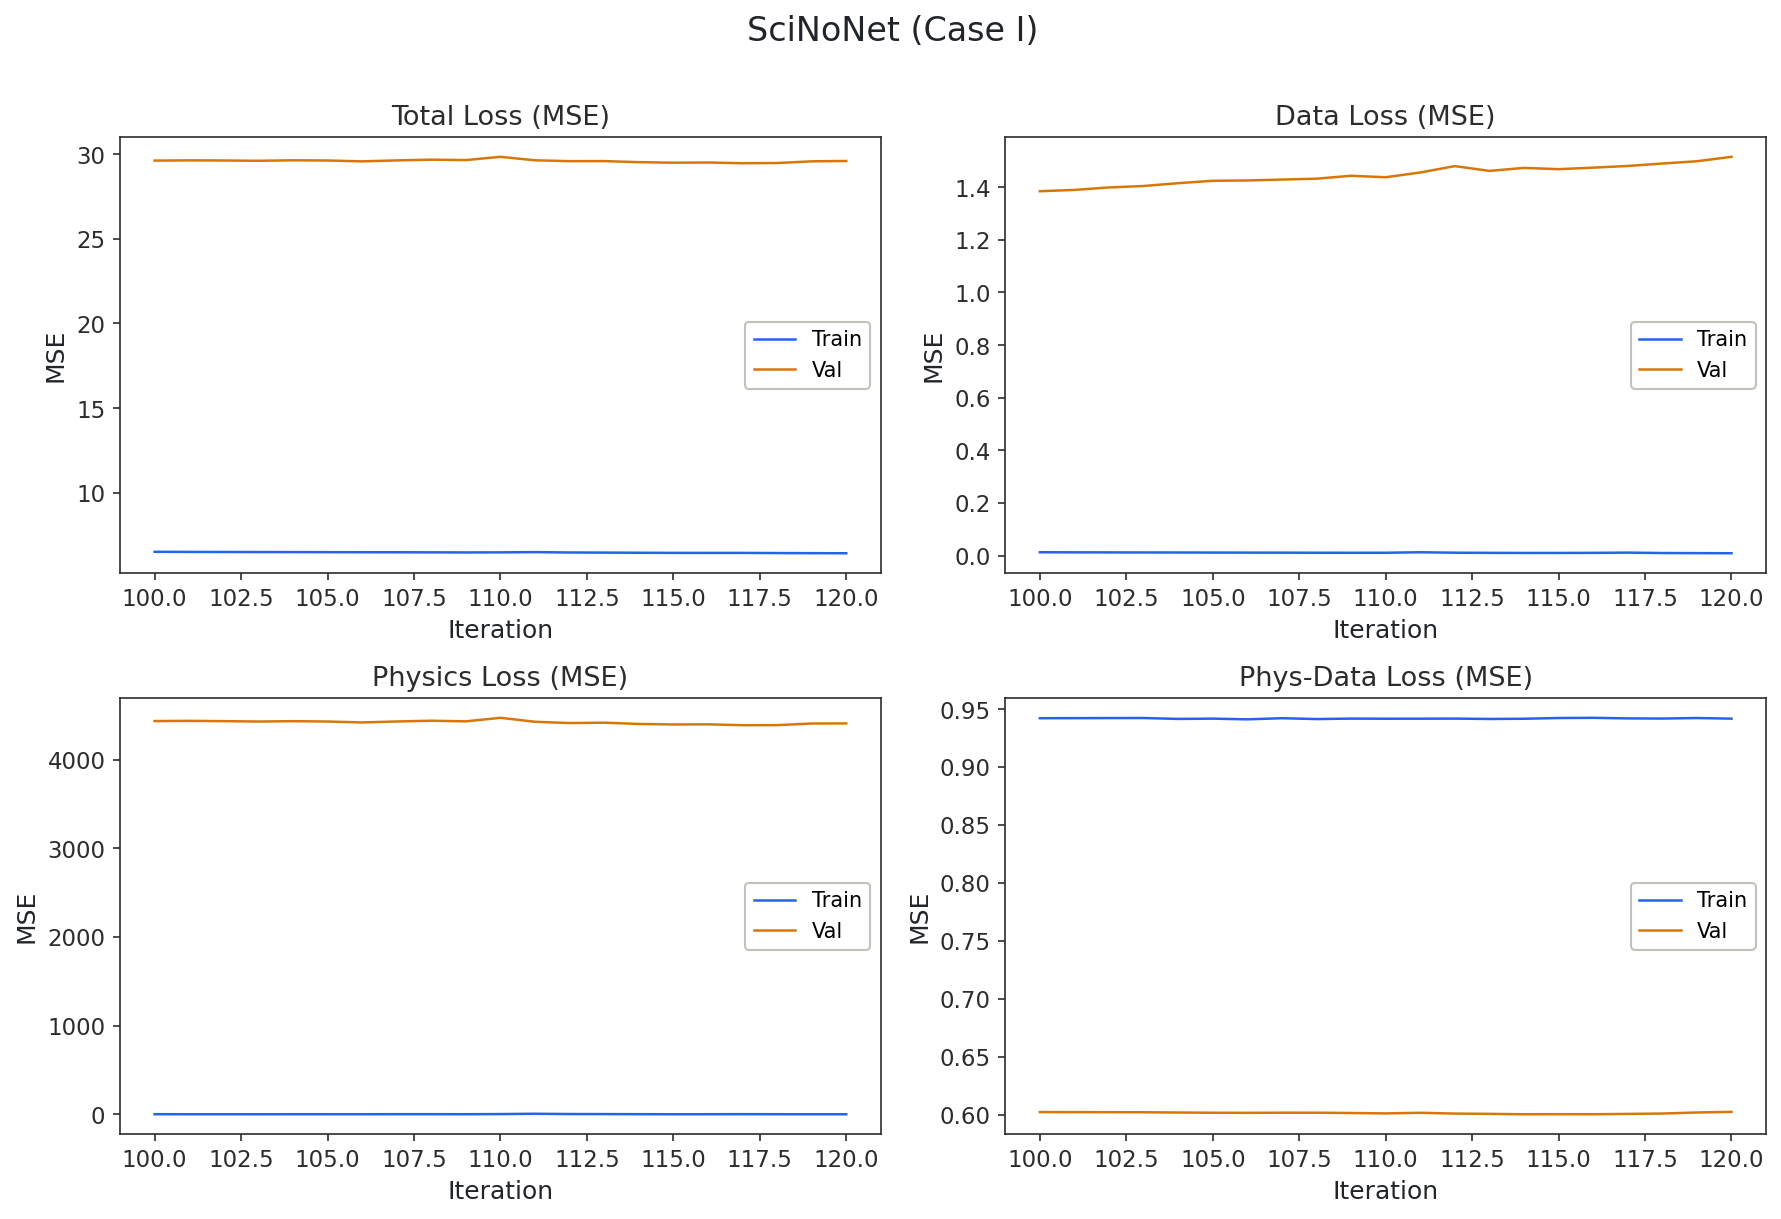

In [28]:
plot_loss_curves(tr_tot, tr_data, tr_phys, tr_physdata,
                 va_tot, va_data, va_phys, va_physdata,
                 epoch_range=(100, 120))


Saved: ./loss_curves.jpg


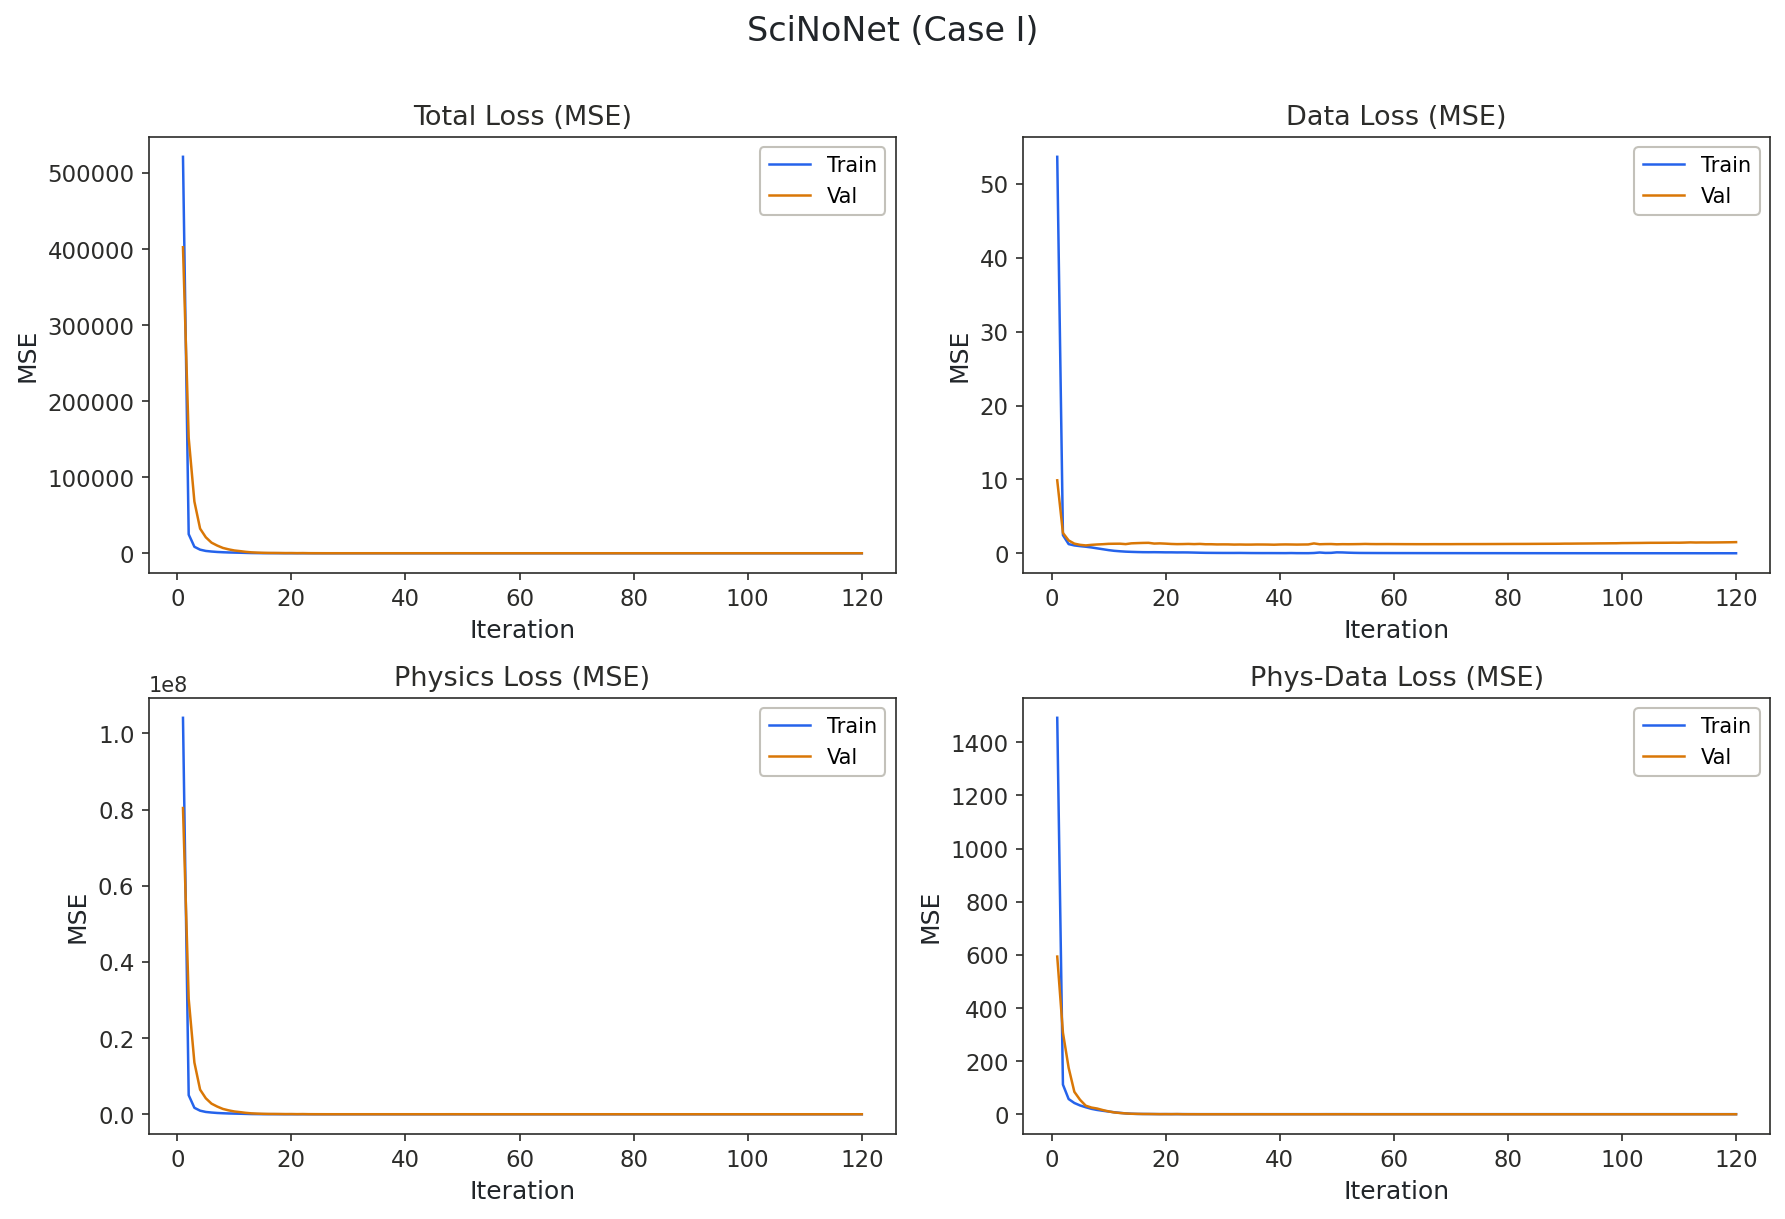

In [29]:
plot_loss_curves(
    tr_tot, tr_data, tr_phys, tr_physdata,
    va_tot, va_data, va_phys, va_physdata,
    save_path='./loss_curves.jpg'
)


In [30]:
def visualize_full_reconstruction(model: torch.nn.Module,
                                  X: torch.Tensor,
                                  full_signal_df: pd.DataFrame,
                                  means: pd.Series,
                                  stds_repl: pd.Series,
                                  point_index: int,
                                  component: str = 'u',
                                  save_path: str | None = None,
                                  figsize: tuple[float, float] = (14, 4)) -> None:
    """Predict full 6001-timestep signal and overlay full ground truth."""
    import matplotlib.pyplot as plt
    import matplotlib as mpl

    mpl.rcParams.update({
        'font.family': 'sans-serif',
        'font.sans-serif': ['Inter', 'Helvetica', 'Arial'],
        'axes.spines.top': True,
        'axes.spines.right': True,
        'axes.grid': False,
        'axes.edgecolor': '#2C2C2A',
        'axes.labelcolor': '#212529',
        'xtick.color': '#2C2C2A',
        'ytick.color': '#2C2C2A',
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
    })

    comp_out = {'u': 0, 'v': 1, 'w': 2}[component]
    dt = 1e-8

    unique_xyz_std = torch.unique(X[:, :3], dim=0)
    xyz_std = unique_xyz_std[point_index]
    xyz_phys = xyz_std.numpy() * stds_repl[['x', 'y', 'z']].values + means[['x', 'y', 'z']].values

    # === Full 6001-step prediction ===
    t_full = np.arange(1, 6002) * dt
    t_full_std = (t_full - means['t']) / stds_repl['t']
    X_full = torch.zeros(6001, 4, dtype=torch.float64)
    X_full[:, 0] = xyz_std[0]
    X_full[:, 1] = xyz_std[1]
    X_full[:, 2] = xyz_std[2]
    X_full[:, 3] = torch.tensor(t_full_std, dtype=torch.float64)

    model.eval()
    with torch.no_grad():
        mag_out, sign_out, _, _ = model(X_full.to(next(model.parameters()).device))
        y_pred_std = reconstruct(mag_out, sign_out).cpu().numpy()

    pred_signal = y_pred_std[:, comp_out] * stds_repl[['u', 'v', 'w']].values[comp_out] \
                  + means[['u', 'v', 'w']].values[comp_out]

    # === Ground truth from full signal dataset ===
    mask = (np.abs(full_signal_df['x'].values - xyz_phys[0]) < 0.1) & \
           (np.abs(full_signal_df['y'].values - xyz_phys[1]) < 0.1)
    gt_grp = full_signal_df[mask].sort_values('t').reset_index(drop=True)
    gt_signal = gt_grp[component].values
    gt_indices = np.round(gt_grp['t'].values / dt - 1).astype(int)

    # === Plot ===
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.plot(gt_indices, gt_signal, color='#212529', linewidth=1.2, label='Ground truth')
    ax.plot(np.arange(6001), pred_signal, color='#DC2626', linewidth=1.5,
            linestyle='--', alpha=0.85, label='Predicted (full)')

    ax.set_xlabel('Timestep index', fontsize=14, fontweight=500)
    ax.set_ylabel(component, fontsize=14, fontweight=500)
    ax.tick_params(labelsize=12, width=1.0, length=4)
    ax.spines[:].set_linewidth(0.8)

    coord_str = f'(x={xyz_phys[0]:.1f}, y={xyz_phys[1]:.1f})'
    ax.set_title(coord_str, fontsize=13, fontweight=500, color='#2C2C2A', pad=10)
    ax.legend(fontsize=11, loc='upper center', ncol=2, frameon=True,
              edgecolor='#B4B2A9', facecolor='white', bbox_to_anchor=(0.5, 1.0))

    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, format='jpeg', dpi=300, bbox_inches='tight', facecolor='white')
        print(f'Saved: {save_path}')
    plt.show()


Saved: ./recon_point0_u.jpg


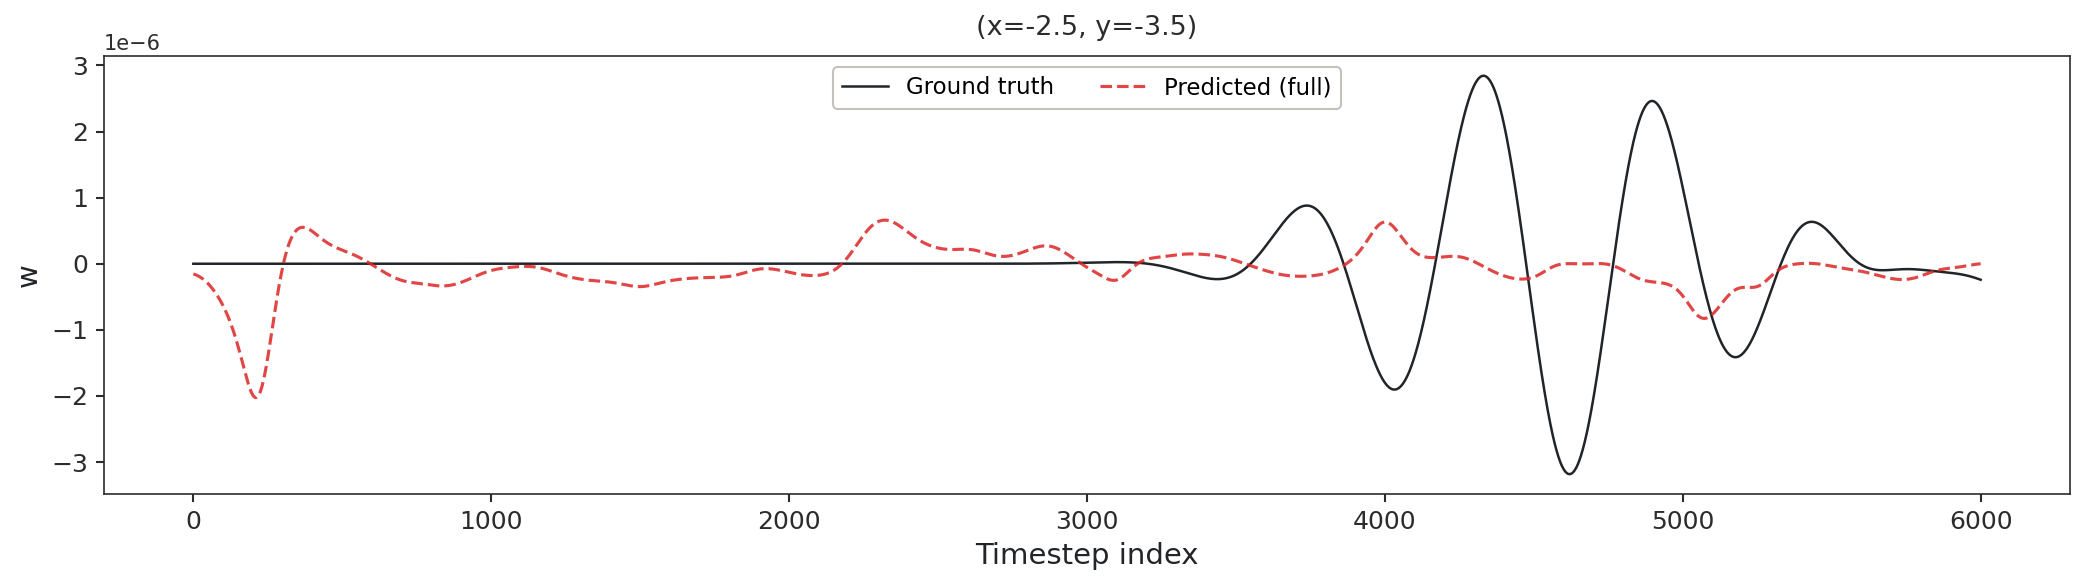

In [31]:
df_full_signal = pd.read_csv('dataset_50_spatialpoints_fullsignal_mixed_rec_neighbor_50inrange.csv')
visualize_full_reconstruction(
    model, X_test, df_full_signal, means, stds_repl,
    point_index= 0, component='w', save_path='./recon_point0_u.jpg'
)


Saved: ./recon_point0_u.jpg


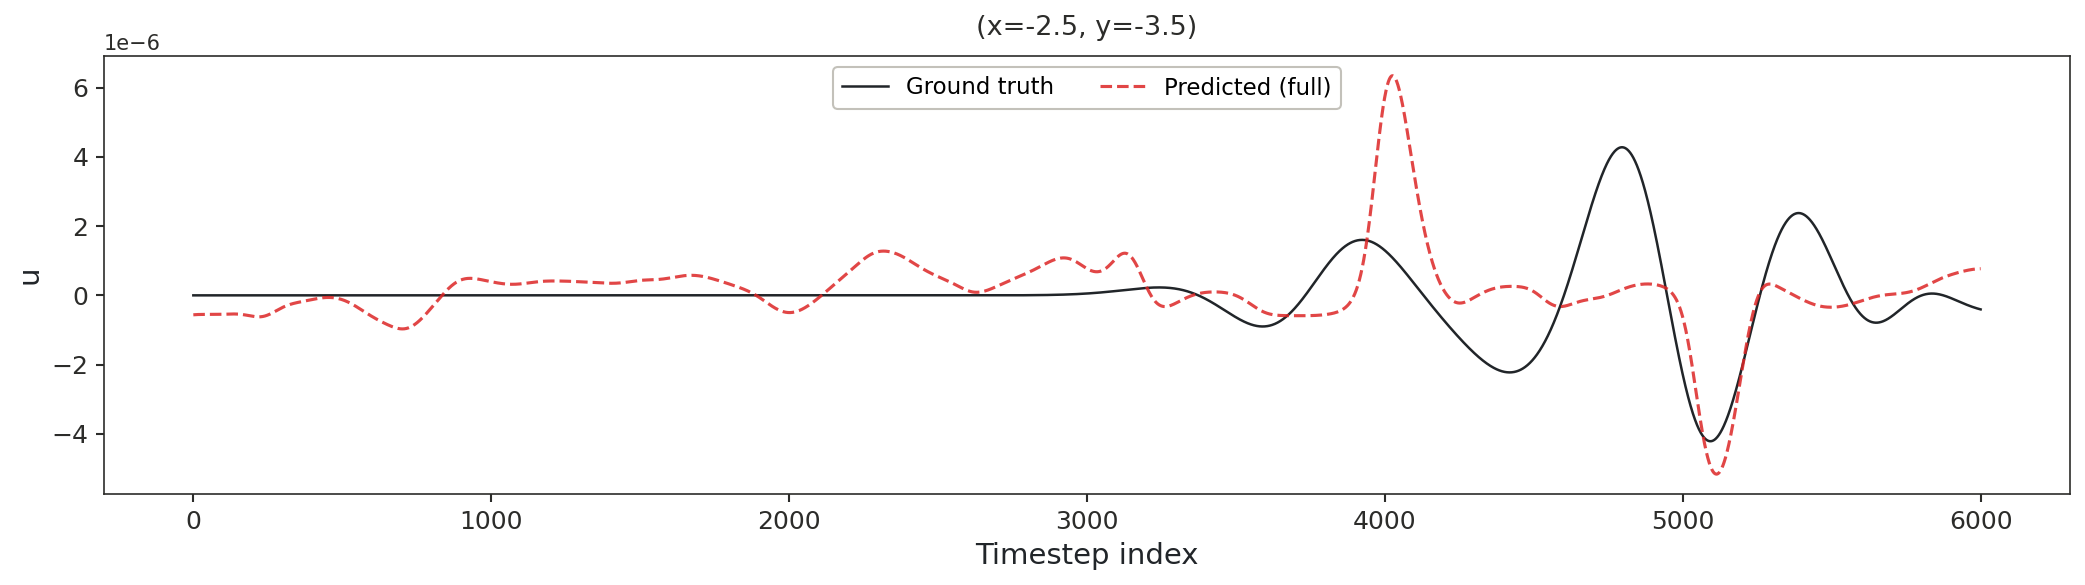

In [32]:
visualize_full_reconstruction(
    model, X_test, df_full_signal, means, stds_repl,
    point_index= 0, component='u', save_path='./recon_point0_u.jpg'
)


In [33]:
ffn = model.module.ffn if isinstance(model, nn.DataParallel) else model.ffn
B = ffn.B.detach().cpu()

print(f"B shape: {B.shape}")
for dim in range(B.shape[0]):
    row = B[dim]
    print(f"  {['x','y','z','t'][dim]}: [{row.min():.4e}, {row.max():.4e}]")


B shape: torch.Size([4, 32])
  x: [-1.8564e+02, 1.5677e+02]
  y: [-9.5500e+01, 1.2395e+02]
  z: [-7.5068e+01, 5.1007e+01]
  t: [-1.6301e+00, 2.4064e+00]
